## Dataset Preparation

In [ ]:
!pip install transformers
!pip install -q transformers datasets
!pip install transformers[torch]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import torch
import torch.nn as nn
import numpy as np
import ast
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BertTokenizerFast, BertForSequenceClassification
from transformers import EvalPrediction
import os
from datasets import load_dataset

In [ ]:
if torch.cuda.is_available():
    device = torch.cuda.get_device_name(0)
    print('GPU device:', device)
else:
    print('No GPU available.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU device: NVIDIA A100-SXM4-40GB


In [ ]:
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/MSc Project/fabsa.csv')


Mounted at /content/gdrive


convert the representation of 'labels' and split the data

In [ ]:
# Convert the string representation of lists in 'labels' column to actual list
df['labels'] = df['labels'].apply(ast.literal_eval)

# Now you can generate the unique list of labels as before
labels = list(set([label for sublist in df['labels'].tolist() for label in sublist]))
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_df.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

all_datasets = {}

dataset_key = "original"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

## Bert

*   Bert-base-uncased
*   Bert-large-uncased



Bert-base-uncased

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average = 'micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data and lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)


    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )

    # Start training
    trainer.train()
    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")
    return result

In [ ]:
# Create a DataFrame to store the results
bertbase_hyperparam_original = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5, 3e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        bertbase_hyperparam_original = bertbase_hyperparam_original.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

Training with original data and lr 5e-05, batch_size 8...


Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.158100,0.090261,0.618020,0.750661,0.346990
2,0.076400,0.073339,0.719180,0.815676,0.473684
3,0.056300,0.066805,0.745549,0.842952,0.506146
4,0.041600,0.064255,0.760841,0.859767,0.521588
5,0.030000,0.064902,0.769416,0.865473,0.529467
6,0.022500,0.064398,0.778372,0.871537,0.537031
7,0.017000,0.066867,0.774416,0.874885,0.533880
8,0.013000,0.067459,0.779658,0.873340,0.540498
9,0.010300,0.067914,0.784679,0.878831,0.547116
10,0.008600,0.068140,0.785274,0.881167,0.547116


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.144051,0.154499,0.541984,0.023322
2,No log,0.112508,0.524227,0.691990,0.261267
3,0.176600,0.096699,0.589685,0.727825,0.318626
4,0.176600,0.086933,0.674963,0.782297,0.405610
5,0.088800,0.080690,0.702110,0.802299,0.447211
6,0.088800,0.077478,0.717042,0.814649,0.470217
7,0.064100,0.075577,0.713851,0.810157,0.468957
8,0.064100,0.073702,0.724397,0.819169,0.480933
9,0.051600,0.073080,0.725294,0.820442,0.483769
10,0.051600,0.072909,0.727237,0.821944,0.481563


Results with original: {'eval_loss': 0.07290863245725632, 'eval_f1': 0.7272365012950788, 'eval_roc_auc': 0.8219444208203185, 'eval_accuracy': 0.4815631894106524, 'eval_runtime': 5.6539, 'eval_samples_per_second': 561.202, 'eval_steps_per_second': 17.687, 'epoch': 10.0}


<ipython-input-8-6baaf3d9fed2>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  bertbase_hyperparam_original = bertbase_hyperparam_original.append({


In [ ]:
# Save the DataFrame to the CSV file
bertbase_hyperparam_original.to_csv('/content/gdrive/My Drive/MSc Project/bertbase_hyperparam_original.csv', index=False)

In [ ]:
# Print out the best hyperparameters
best_hyperparams = bertbase_hyperparam_original.loc[bertbase_hyperparam_original['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-base-uncased model:
learning_rate       0.000050
train_batch_size    8.000000
f1_score            0.785274
Name: 0, dtype: float64


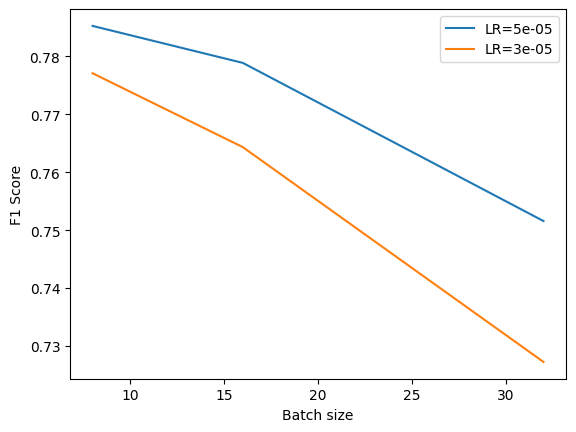

In [ ]:
# Plot the results
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    temp_df = bertbase_hyperparam_original[bertbase_hyperparam_original['learning_rate'] == lr]
    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
bertbase_hyperparam_original

,learning_rate,train_batch_size,f1_score
0,0.00005,8.0,0.785274
1,0.00005,16.0,0.778885
2,0.00005,32.0,0.751570
3,0.00003,8.0,0.777100
4,0.00003,16.0,0.764331
5,0.00003,32.0,0.727237


## Bert-large-uncased

In [ ]:
# Initialize tokenizer and define model
tokenizer = BertTokenizerFast.from_pretrained("bert-large-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given augmented dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data and lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    model = BertForSequenceClassification.from_pretrained("bert-large-uncased", num_labels=len(labels))

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    # Start training
    trainer.train()
    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")
    return result


Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_df = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5, 3e-5, 2e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/bertlarge_hyperparam_df10.csv', index=False)


Training with original data and lr 5e-05, batch_size 8...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.145200,0.089620,0.610274,0.744141,0.364324
2,0.072600,0.078399,0.688748,0.835206,0.481878
3,0.055500,0.065624,0.745404,0.852716,0.485975
4,0.040900,0.063090,0.770811,0.872930,0.523479
5,0.029600,0.062736,0.779006,0.884119,0.531673
6,0.021400,0.064434,0.777707,0.877477,0.535771
7,0.015000,0.068698,0.782953,0.891271,0.530413
8,0.010000,0.068855,0.790288,0.890771,0.546171
9,0.007500,0.068856,0.795071,0.891822,0.552789
10,0.005600,0.069461,0.795913,0.894097,0.554050


Results with original: {'eval_loss': 0.06946144253015518, 'eval_f1': 0.7959129275877388, 'eval_roc_auc': 0.8940970477942625, 'eval_accuracy': 0.5540497951465491, 'eval_runtime': 26.7222, 'eval_samples_per_second': 118.74, 'eval_steps_per_second': 14.857, 'epoch': 10.0}
Training with original data and lr 5e-05, batch_size 16...


<ipython-input-25-f682f4bee6a9>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Results with original: {'eval_loss': 0.0628180280327797, 'eval_f1': 0.7841753343239227, 'eval_roc_auc': 0.8722338957555485, 'eval_accuracy': 0.5556255909234163, 'eval_runtime': 23.6883, 'eval_samples_per_second': 133.948, 'eval_steps_per_second': 8.401, 'epoch': 10.0}
Training with original data and lr 2e-05, batch_size 32...


<ipython-input-25-f682f4bee6a9>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.128746,0.348458,0.611437,0.107154
2,No log,0.094767,0.607293,0.735993,0.331863
3,0.155300,0.081572,0.705846,0.801245,0.444374
4,0.155300,0.075250,0.728214,0.822493,0.479987
5,0.071900,0.070765,0.748228,0.839783,0.510243
6,0.071900,0.067357,0.754143,0.839502,0.515916
7,0.047900,0.065810,0.753421,0.837989,0.516861
8,0.047900,0.066409,0.761205,0.851866,0.522219
9,0.035000,0.065199,0.765378,0.851884,0.535140
10,0.035000,0.064828,0.766979,0.853701,0.535455


Results with original: {'eval_loss': 0.06482843309640884, 'eval_f1': 0.7669791467380908, 'eval_roc_auc': 0.8537013081062658, 'eval_accuracy': 0.5354554049795146, 'eval_runtime': 22.8445, 'eval_samples_per_second': 138.895, 'eval_steps_per_second': 4.377, 'epoch': 10.0}


<ipython-input-25-f682f4bee6a9>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_df.loc[hyperparam_results_df['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-large-uncased model:
learning_rate        0.000050
train_batch_size    32.000000
f1_score             0.796325
Name: 2, dtype: float64


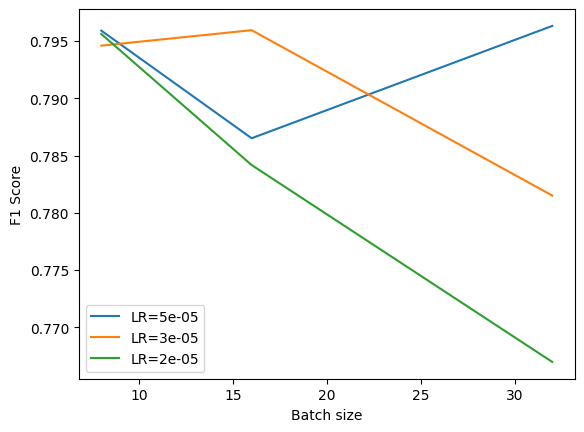

In [ ]:
# Plot the results
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    temp_df = hyperparam_results_df[hyperparam_results_df['learning_rate'] == lr]
    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_results_df

,learning_rate,train_batch_size,f1_score
0,0.00005,8.0,0.795913
1,0.00005,16.0,0.786515
2,0.00005,32.0,0.796325
3,0.00003,8.0,0.794604
4,0.00003,16.0,0.795952
5,0.00003,32.0,0.781509
6,0.00002,8.0,0.795620
7,0.00002,16.0,0.784175
8,0.00002,32.0,0.766979


## Roberta

*   Roberta-base
*   Roberta-large



Roberta-base

In [ ]:
# Preprocess data
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

def preprocess_data(examples):
  text = examples["text"]
  encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

  labels_batch = examples["labels"]
  labels_matrix = np.zeros((len(text), len(labels)))

  for i, label_list in enumerate(labels_batch):
    for label in label_list:
      idx = label2id[label]
      labels_matrix[i, idx] = 1

  encoding["labels"] = labels_matrix.tolist()

  return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average = 'micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data and lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = RobertaForSequenceClassification.from_pretrained("roberta-base",
                                                         num_labels=len(labels))

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"roberta-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    # Start training
    trainer.train()
    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")
    return result


Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_df = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5, 3e-5, 2e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/robertabase_hyperparam_df10.csv', index=False)

Training with original data and lr 5e-05, batch_size 8...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.157100,0.092101,0.599623,0.738142,0.328396
2,0.082900,0.072438,0.715950,0.814256,0.468642
3,0.063200,0.066626,0.728739,0.822770,0.486921
4,0.050800,0.064398,0.758321,0.860664,0.508982
5,0.040100,0.063634,0.773483,0.876462,0.534825
6,0.033500,0.061935,0.773443,0.871628,0.539868
7,0.027600,0.065112,0.779661,0.884081,0.537662
8,0.021800,0.064161,0.783646,0.878846,0.541128
9,0.018000,0.065001,0.786103,0.881467,0.551213
10,0.015000,0.065386,0.786541,0.882726,0.553104


Results with original: {'eval_loss': 0.06538629531860352, 'eval_f1': 0.7865412445730826, 'eval_roc_auc': 0.882726149794934, 'eval_accuracy': 0.5531043176804287, 'eval_runtime': 8.3093, 'eval_samples_per_second': 381.861, 'eval_steps_per_second': 47.778, 'epoch': 10.0}
Training with original data and lr 5e-05, batch_size 16...


<ipython-input-11-636a515db0fe>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

<ipython-input-11-636a515db0fe>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.144848,0.118278,0.531614,0.013867
2,No log,0.111601,0.545626,0.704261,0.277340
3,0.174900,0.094716,0.642132,0.759407,0.362118
4,0.174900,0.087461,0.674639,0.785802,0.410022


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.144848,0.118278,0.531614,0.013867
2,No log,0.111601,0.545626,0.704261,0.277340
3,0.174900,0.094716,0.642132,0.759407,0.362118
4,0.174900,0.087461,0.674639,0.785802,0.410022
5,0.091600,0.080520,0.718364,0.813114,0.470533
6,0.091600,0.076903,0.725443,0.818099,0.474945
7,0.070900,0.073368,0.736715,0.824490,0.496061
8,0.070900,0.072552,0.740631,0.832137,0.502679
9,0.060200,0.070997,0.742323,0.829802,0.506146
10,0.060200,0.070766,0.747389,0.834841,0.511818


Results with original: {'eval_loss': 0.07076600193977356, 'eval_f1': 0.7473891625615764, 'eval_roc_auc': 0.8348413094488066, 'eval_accuracy': 0.5118184683265049, 'eval_runtime': 7.0466, 'eval_samples_per_second': 450.285, 'eval_steps_per_second': 14.191, 'epoch': 10.0}


<ipython-input-11-636a515db0fe>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_df.loc[hyperparam_results_df['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-base-uncased model:
learning_rate       0.000030
train_batch_size    8.000000
f1_score            0.794176
Name: 3, dtype: float64


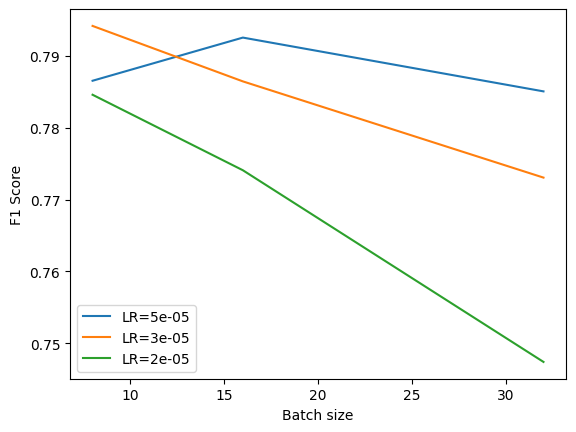

In [ ]:
# Plot the results
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    temp_df = hyperparam_results_df[hyperparam_results_df['learning_rate'] == lr]
    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_results_df

,learning_rate,train_batch_size,f1_score
0,0.00005,8.0,0.786541
1,0.00005,16.0,0.792552
2,0.00005,32.0,0.785062
3,0.00003,8.0,0.794176
4,0.00003,16.0,0.786453
5,0.00003,32.0,0.773055
6,0.00002,8.0,0.784591
7,0.00002,16.0,0.774078
8,0.00002,32.0,0.747389


## Roberta-large

In [ ]:
# Preprocess data
tokenizer = RobertaTokenizerFast.from_pretrained("roberta-large")

def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result



# Function to train and evaluate the model for a given augmented dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data and lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = RobertaForSequenceClassification.from_pretrained("roberta-large", num_labels=len(labels))

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"robertalarge-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    # Start training
    trainer.train()
    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")
    return result

Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_df = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_df10.csv', index=False)

Training with original data and lr 5e-05, batch_size 8...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.164000,0.154879,0.000000,0.500000,0.000000
2,0.152500,0.159641,0.000000,0.500000,0.000000
3,0.149400,0.162563,0.000000,0.500000,0.000000
4,0.147700,0.162087,0.000000,0.500000,0.000000
5,0.147000,0.163204,0.000000,0.500000,0.000000
6,0.146700,0.164061,0.000000,0.500000,0.000000
7,0.145500,0.165972,0.000000,0.500000,0.000000
8,0.145900,0.166702,0.000000,0.500000,0.000000
9,0.146100,0.165682,0.000000,0.500000,0.000000
10,0.144200,0.166718,0.000000,0.500000,0.000000


Results with original: {'eval_loss': 0.1548786163330078, 'eval_f1': 0.0, 'eval_roc_auc': 0.5, 'eval_accuracy': 0.0, 'eval_runtime': 20.2571, 'eval_samples_per_second': 156.637, 'eval_steps_per_second': 19.598, 'epoch': 10.0}
Training with original data and lr 5e-05, batch_size 16...


<ipython-input-9-e7f59962e640>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Results with original: {'eval_loss': 0.15633028745651245, 'eval_f1': 0.0, 'eval_roc_auc': 0.5, 'eval_accuracy': 0.0, 'eval_runtime': 18.0922, 'eval_samples_per_second': 175.379, 'eval_steps_per_second': 10.999, 'epoch': 10.0}
Training with original data and lr 5e-05, batch_size 32...


<ipython-input-9-e7f59962e640>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.121788,0.217709,0.563353,0.041601
2,No log,0.083782,0.661432,0.778129,0.417586
3,0.127800,0.068392,0.741582,0.836754,0.500788
4,0.127800,0.063924,0.760439,0.856800,0.513709
5,0.063200,0.059540,0.786552,0.878212,0.548062
6,0.063200,0.058032,0.786046,0.879985,0.560038
7,0.042000,0.057656,0.792743,0.881316,0.558777
8,0.042000,0.057770,0.795313,0.888549,0.565711
9,0.028600,0.058193,0.795403,0.884280,0.571068
10,0.028600,0.058624,0.797973,0.888555,0.573905


Results with original: {'eval_loss': 0.05862433463335037, 'eval_f1': 0.7979734008866372, 'eval_roc_auc': 0.8885551420459485, 'eval_accuracy': 0.5739048219350772, 'eval_runtime': 17.0052, 'eval_samples_per_second': 186.59, 'eval_steps_per_second': 5.881, 'epoch': 10.0}


<ipython-input-9-e7f59962e640>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [3e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_df10.csv', index=False)

Training with original data and lr 3e-05, batch_size 8...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.153300,0.083519,0.664513,0.780651,0.403719
2,0.076100,0.063172,0.752907,0.842688,0.507721
3,0.055500,0.060134,0.770449,0.860384,0.529152
4,0.044100,0.057895,0.790214,0.881320,0.562874
5,0.034300,0.058379,0.792570,0.881716,0.569493
6,0.027400,0.058000,0.802821,0.891332,0.578317
7,0.020700,0.060064,0.798405,0.888089,0.576426
8,0.015100,0.061188,0.802204,0.897384,0.574535
9,0.012200,0.061064,0.806280,0.893857,0.587142
10,0.009700,0.061818,0.807513,0.895995,0.589978


Results with original: {'eval_loss': 0.06181805580854416, 'eval_f1': 0.8075125808770669, 'eval_roc_auc': 0.8959947497313226, 'eval_accuracy': 0.5899779388591239, 'eval_runtime': 20.266, 'eval_samples_per_second': 156.568, 'eval_steps_per_second': 19.589, 'epoch': 10.0}
Training with original data and lr 3e-05, batch_size 16...


<ipython-input-16-6c4c38b4e986>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Results with original: {'eval_loss': 0.05977960675954819, 'eval_f1': 0.805304944063515, 'eval_roc_auc': 0.8933834887961396, 'eval_accuracy': 0.5820989599747872, 'eval_runtime': 18.0992, 'eval_samples_per_second': 175.312, 'eval_steps_per_second': 10.995, 'epoch': 10.0}
Training with original data and lr 3e-05, batch_size 32...


<ipython-input-16-6c4c38b4e986>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.116407,0.494035,0.684540,0.210841
2,No log,0.078121,0.699429,0.797208,0.448471
3,0.127800,0.066821,0.758392,0.853238,0.513079
4,0.127800,0.061828,0.775021,0.864850,0.531358
5,0.057800,0.058736,0.794591,0.883242,0.564765
6,0.057800,0.058021,0.799228,0.883616,0.574535
7,0.036100,0.057589,0.799779,0.883075,0.571068
8,0.036100,0.058220,0.804294,0.889778,0.582099
9,0.024500,0.057452,0.804703,0.886510,0.582099
10,0.024500,0.058224,0.804197,0.888702,0.578002


Results with original: {'eval_loss': 0.05745247006416321, 'eval_f1': 0.8047032886275952, 'eval_roc_auc': 0.8865100647568038, 'eval_accuracy': 0.5820989599747872, 'eval_runtime': 17.0337, 'eval_samples_per_second': 186.277, 'eval_steps_per_second': 5.871, 'epoch': 10.0}


<ipython-input-16-6c4c38b4e986>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [2e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/robertalarge_hyperparam_df10.csv', index=False)

Training with original data and lr 2e-05, batch_size 8...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.154800,0.077327,0.685671,0.782898,0.435550
2,0.069300,0.061148,0.764506,0.847333,0.527261
3,0.052000,0.057837,0.787256,0.874727,0.552474
4,0.040100,0.056397,0.801160,0.889581,0.575165
5,0.030200,0.058046,0.801735,0.890934,0.576426
6,0.024000,0.058289,0.801341,0.889839,0.576111
7,0.018800,0.059573,0.800036,0.887287,0.575481
8,0.014000,0.061310,0.802484,0.892875,0.571068
9,0.011700,0.061296,0.803904,0.892059,0.577056
10,0.009600,0.061830,0.805101,0.892382,0.579578


Results with original: {'eval_loss': 0.06182975322008133, 'eval_f1': 0.8051008410961381, 'eval_roc_auc': 0.892382253741357, 'eval_accuracy': 0.5795776867317995, 'eval_runtime': 20.2892, 'eval_samples_per_second': 156.388, 'eval_steps_per_second': 19.567, 'epoch': 10.0}
Training with original data and lr 2e-05, batch_size 16...


<ipython-input-19-893e7bd8fee1>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Results with original: {'eval_loss': 0.058303482830524445, 'eval_f1': 0.8096621867054123, 'eval_roc_auc': 0.8932459470070278, 'eval_accuracy': 0.5902930980144974, 'eval_runtime': 18.0702, 'eval_samples_per_second': 175.593, 'eval_steps_per_second': 11.013, 'epoch': 10.0}
Training with original data and lr 2e-05, batch_size 32...


<ipython-input-19-893e7bd8fee1>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.107737,0.554362,0.707039,0.267570
2,No log,0.077648,0.710732,0.801793,0.461078
3,0.131100,0.068056,0.766173,0.853651,0.527892
4,0.131100,0.062565,0.773382,0.857948,0.539868
5,0.060300,0.059508,0.790867,0.874378,0.559723
6,0.060300,0.058600,0.791983,0.873216,0.565080
7,0.040200,0.057986,0.787822,0.871068,0.560983
8,0.040200,0.058279,0.799300,0.882633,0.577372
9,0.029300,0.057754,0.795916,0.878392,0.575796
10,0.029300,0.058006,0.797606,0.882034,0.579263


Results with original: {'eval_loss': 0.05827900022268295, 'eval_f1': 0.7992996682639145, 'eval_roc_auc': 0.8826334600886389, 'eval_accuracy': 0.5773715726441853, 'eval_runtime': 17.103, 'eval_samples_per_second': 185.523, 'eval_steps_per_second': 5.847, 'epoch': 10.0}


<ipython-input-19-893e7bd8fee1>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_df.loc[hyperparam_results_df['f1_score'].idxmax()]
print(f"Best hyperparameters for roberta-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for roberta-large-uncased model:
learning_rate        0.000020
train_batch_size    16.000000
f1_score             0.809662
Name: 7, dtype: float64


In [ ]:
hyperparam_results_df

,learning_rate,train_batch_size,f1_score
0,0.00005,8.0,0.000000
1,0.00005,16.0,0.000000
2,0.00005,32.0,0.797973
3,0.00003,8.0,0.807513
4,0.00003,16.0,0.805305
5,0.00003,32.0,0.804703
6,0.00002,8.0,0.805101
7,0.00002,16.0,0.809662
8,0.00002,32.0,0.799300


## XLnet


*   XLnet-base-cased
*   XLnet-large-cased



XLnet-base-cased

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlnet-base-cased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data, lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])
    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")
    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("xlnet-base-cased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )

    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # Start training
    trainer.train()

    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")

    return result

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_df = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5, 3e-5, 2e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/xlnetbase_hyperparam_df10.csv', index=False)

Training with original data, lr 5e-05, batch_size 8...


Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'sequence_summary.summary.weight', 'logits_proj.weight', 'logits_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.164900,0.153078,0.000000,0.500000,0.000000
2,0.151300,0.153127,0.000000,0.500000,0.000000
3,0.152700,0.153210,0.000000,0.500000,0.000000
4,0.152300,0.152714,0.000000,0.500000,0.000000
5,0.147800,0.148050,0.000000,0.500000,0.000000
6,0.149300,0.152310,0.000000,0.500000,0.000000
7,0.148400,0.155391,0.005661,0.501284,0.000000
8,0.146500,0.156005,0.001069,0.500249,0.000000
9,0.145300,0.155991,0.000000,0.500000,0.000000
10,0.144100,0.154608,0.000000,0.500000,0.000000


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'sequence_summary.summary.weight', 'logits_proj.weight', 'logits_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.131558,0.351749,0.613847,0.077529
2,No log,0.099932,0.590402,0.732644,0.301607
3,0.152800,0.085860,0.686533,0.793402,0.426410
4,0.152800,0.078820,0.704501,0.804389,0.455090
5,0.081700,0.074146,0.730040,0.825694,0.486921
6,0.081700,0.070809,0.735975,0.830784,0.493539
7,0.062100,0.069458,0.737100,0.831262,0.494800
8,0.062100,0.068289,0.746205,0.838107,0.503939
9,0.051600,0.067102,0.748519,0.839801,0.508982
10,0.051600,0.066852,0.752414,0.843554,0.512449


Results with original: {'eval_loss': 0.06685221195220947, 'eval_f1': 0.7524140594824256, 'eval_roc_auc': 0.8435537739851653, 'eval_accuracy': 0.5124487866372518, 'eval_runtime': 11.7902, 'eval_samples_per_second': 269.122, 'eval_steps_per_second': 8.482, 'epoch': 10.0}


<ipython-input-19-e6d88dd73960>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_df.loc[hyperparam_results_df['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-base model:\n{best_hyperparams}")

Best hyperparameters for xlnet-base model:
learning_rate       0.000030
train_batch_size    8.000000
f1_score            0.785533
Name: 3, dtype: float64


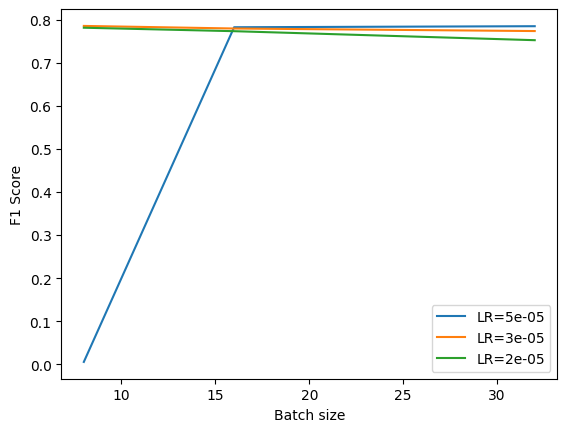

In [ ]:
# Plot the results
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    temp_df = hyperparam_results_df[hyperparam_results_df['learning_rate'] == lr]
    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_results_df

,learning_rate,train_batch_size,f1_score
0,0.00005,8.0,0.005661
1,0.00005,16.0,0.782475
2,0.00005,32.0,0.784875
3,0.00003,8.0,0.785533
4,0.00003,16.0,0.779543
5,0.00003,32.0,0.773617
6,0.00002,8.0,0.781348
7,0.00002,16.0,0.773316
8,0.00002,32.0,0.752414


## XLnet-large-cased

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlnet-large-cased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data, lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("xlnet-large-cased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )

    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # Start training
    trainer.train()

    # Evaluation
    result = trainer.evaluate()
    print(f"Results with {dataset_key}, lr={lr} and batch_size={batch_size}: {result}")
    return result

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_df = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/xlnetlarge_hyperparam_df10.csv', index=False)

Training with original data, lr 5e-05, batch_size 8...


Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.bias', 'sequence_summary.summary.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a XLNetTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.163900,0.153546,0.000000,0.500000,0.000000
2,0.152900,0.153382,0.000000,0.500000,0.000000
3,0.153000,0.153601,0.000000,0.500000,0.000000
4,0.151700,0.154324,0.000000,0.500000,0.000000
5,0.148400,0.161465,0.000000,0.500000,0.000000
6,0.146700,0.161636,0.000000,0.500000,0.000000
7,0.145900,0.163418,0.000000,0.500000,0.000000
8,0.145800,0.164201,0.000000,0.500000,0.000000
9,0.145600,0.164356,0.000000,0.500000,0.000000
10,0.143900,0.164670,0.000000,0.500000,0.000000


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.bias', 'sequence_summary.summary.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.115930,0.314673,0.597635,0.078790
2,No log,0.085485,0.631024,0.758110,0.364009
3,0.126200,0.070664,0.735392,0.840337,0.484084
4,0.126200,0.063513,0.758187,0.850939,0.515285
5,0.061300,0.059545,0.791187,0.884257,0.552474
6,0.061300,0.058835,0.792022,0.884722,0.558147
7,0.034200,0.060573,0.792181,0.887115,0.549322
8,0.034200,0.060679,0.799144,0.894553,0.563505
9,0.019300,0.060357,0.800824,0.893756,0.562559
10,0.019300,0.060702,0.803818,0.896747,0.566656


Results with original, lr=5e-05 and batch_size=32: {'eval_loss': 0.06070152670145035, 'eval_f1': 0.8038183602462307, 'eval_roc_auc': 0.8967474163561372, 'eval_accuracy': 0.5666561613614876, 'eval_runtime': 22.3044, 'eval_samples_per_second': 142.259, 'eval_steps_per_second': 4.483, 'epoch': 10.0}


<ipython-input-26-9cdc4202465a>:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [3e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/xlnetlarge_hyperparam_df10.csv', index=False)

Training with original data, lr 3e-05, batch_size 8...


Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.bias', 'sequence_summary.summary.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.155400,0.100287,0.549441,0.713084,0.269461
2,0.089000,0.070178,0.730845,0.826314,0.479672
3,0.062800,0.065989,0.743795,0.839338,0.498897
4,0.047600,0.059345,0.784207,0.879457,0.543019
5,0.034500,0.058856,0.798186,0.894903,0.555941
6,0.026100,0.059942,0.798792,0.895847,0.558462
7,0.019700,0.062385,0.798789,0.894859,0.560668
8,0.014600,0.063339,0.804308,0.900978,0.564135
9,0.011300,0.064203,0.805095,0.897982,0.567917
10,0.008700,0.064390,0.805867,0.899185,0.566341


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.bias', 'sequence_summary.summary.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.103288,0.582172,0.731048,0.295304
2,No log,0.071962,0.713181,0.805666,0.463284
3,0.123000,0.063127,0.775040,0.867144,0.529783
4,0.123000,0.059232,0.779512,0.867674,0.534510
5,0.053900,0.056647,0.802103,0.889970,0.561614
6,0.053900,0.056831,0.797806,0.884761,0.562559
7,0.032300,0.058181,0.802015,0.892763,0.564135
8,0.032300,0.059410,0.802402,0.894351,0.564765
9,0.021100,0.058736,0.802627,0.893049,0.569493
10,0.021100,0.058831,0.804946,0.893031,0.574850


Results with original, lr=3e-05 and batch_size=32: {'eval_loss': 0.058830998837947845, 'eval_f1': 0.8049462947919488, 'eval_roc_auc': 0.8930313313015847, 'eval_accuracy': 0.5748502994011976, 'eval_runtime': 22.3499, 'eval_samples_per_second': 141.969, 'eval_steps_per_second': 4.474, 'epoch': 10.0}


<ipython-input-28-7272baaf1c27>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [2e-5],
    'train_batch_size': [8, 16, 32],
}

# Select only the "original" dataset
dataset_key = "original"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_df = hyperparam_results_df.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_df.to_csv('/content/gdrive/My Drive/MSc Project/xlnetlarge_hyperparam_df10.csv', index=False)

Training with original data, lr 2e-05, batch_size 8...


Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.bias', 'sequence_summary.summary.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.168100,0.120855,0.369350,0.627385,0.110936
2,0.113200,0.100865,0.550676,0.717183,0.303813
3,0.088100,0.084528,0.661932,0.790145,0.400567
4,0.071000,0.074539,0.723327,0.833855,0.474630
5,0.055700,0.068221,0.745609,0.847354,0.503309
6,0.045700,0.066215,0.757996,0.853784,0.521904
7,0.037800,0.065680,0.771334,0.869853,0.528837
8,0.030000,0.065641,0.777859,0.873634,0.537346
9,0.024800,0.065611,0.781896,0.877913,0.543965
10,0.020400,0.065960,0.784757,0.881544,0.550268


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.bias', 'sequence_summary.summary.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.119486,0.432043,0.658525,0.127639
2,No log,0.090203,0.612092,0.744265,0.353924
3,0.138900,0.077790,0.713341,0.822500,0.466436
4,0.138900,0.071441,0.735263,0.840573,0.493224
5,0.070500,0.065884,0.759678,0.857568,0.520643
6,0.070500,0.063990,0.764894,0.858557,0.526946
7,0.048800,0.063589,0.771865,0.865385,0.531043
8,0.048800,0.062857,0.777623,0.869276,0.538292
9,0.035600,0.062211,0.782946,0.873058,0.546486
10,0.035600,0.062654,0.780700,0.871439,0.543650


Results with original, lr=2e-05 and batch_size=32: {'eval_loss': 0.06221134960651398, 'eval_f1': 0.782946453343198, 'eval_roc_auc': 0.8730584813945277, 'eval_accuracy': 0.5464859754175859, 'eval_runtime': 22.3059, 'eval_samples_per_second': 142.249, 'eval_steps_per_second': 4.483, 'epoch': 10.0}


<ipython-input-30-db8180149416>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_df = hyperparam_results_df.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_df.loc[hyperparam_results_df['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-large model:\n{best_hyperparams}")

Best hyperparameters for xlnet-large model:
learning_rate       0.000030
train_batch_size    8.000000
f1_score            0.805867
Name: 3, dtype: float64


In [ ]:
hyperparam_results_df

,learning_rate,train_batch_size,f1_score
0,0.00005,8.0,0.000000
1,0.00005,16.0,0.764607
2,0.00005,32.0,0.803818
3,0.00003,8.0,0.805867
4,0.00003,16.0,0.000000
5,0.00003,32.0,0.804946
6,0.00002,8.0,0.784757
7,0.00002,16.0,0.803700
8,0.00002,32.0,0.782946
